In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.DataFrame({
    'Order_ID': [101,102,103,104,105,106,107,108,109,110],
    'Order_Amount': [550,620,700,680,720,650,710,690,640,18000]
})

In [2]:
Q1 = orders['Order_Amount'].quantile(0.25)
Q2 = orders['Order_Amount'].quantile(0.50)
Q3 = orders['Order_Amount'].quantile(0.75)

In [7]:
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1           : {Q1}")
print(f"Median (Q2)  : {Q2}")
print(f"Q3           : {Q3}")
print(f"IQR          : {IQR}")
print(f"Lower Fence  : {lower_fence}")
print(f"Upper Fence  : {upper_fence}")

Q1           : 642.5
Median (Q2)  : 685.0
Q3           : 707.5
IQR          : 65.0
Lower Fence  : 545.0
Upper Fence  : 805.0


In [9]:
outliers = orders[(orders['Order_Amount'] < lower_fence) | (orders['Order_Amount'] > upper_fence)]
outliers

,Order_ID,Order_Amount
9,110,18000


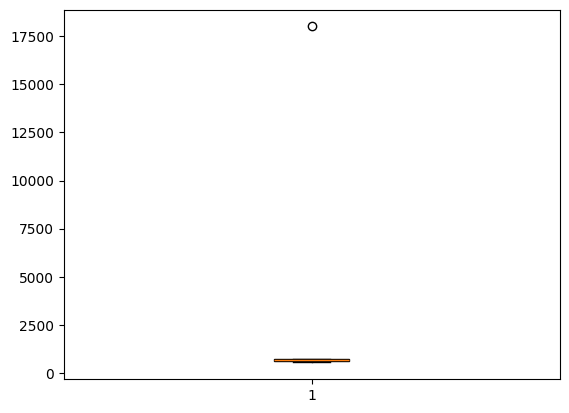

In [6]:
plt.boxplot(
    orders['Order_Amount'],
    vert=True,
    patch_artist=True
)
plt.show()

In [10]:
delivery_time = [
    28,30,27,31,29,30,32,28,29,31,
    30,27,29,30,31,28,29,30,32,31,
    29,30,28,29,30,31,29,30,28,29,
    30,31,30,29,28,85,90,95,100,110
]

df = pd.DataFrame({
    "Delivery_Time": delivery_time
})

In [11]:
df.head()

,Delivery_Time
0,28
1,30
2,27
3,31
4,29


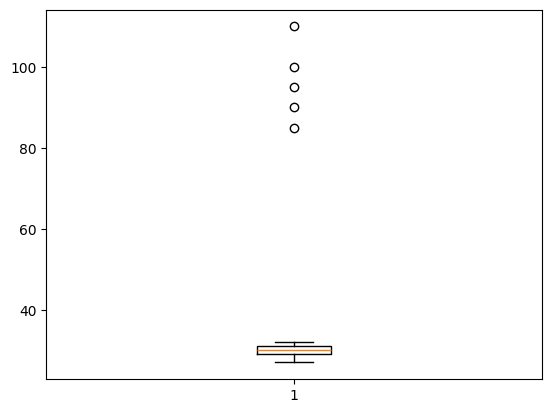

In [13]:
plt.boxplot(df)
plt.show()

In [14]:
Q1 = df["Delivery_Time"].quantile(0.25)
Q3 = df["Delivery_Time"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)

Q1 : 29.0
Q3 : 31.0
IQR: 2.0


In [15]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [25]:
outliers = df[(df["Delivery_Time"] < lower_bound) | (df["Delivery_Time"] > upper_bound)]
outliers

,Delivery_Time
35,85
36,90
37,95
38,100
39,110


In [26]:
clean_df = df[
    (df["Delivery_Time"] >= lower_bound) &
    (df["Delivery_Time"] <= upper_bound)
]

print("\nCleaned Dataset")
print(clean_df)

# -----------------------------
# Step 8: Compare Mean & Median
# -----------------------------
print("\nBefore Removing Outliers")
print("Mean   :", df["Delivery_Time"].mean())
print("Median :", df["Delivery_Time"].median())

print("\nAfter Removing Outliers")
print("Mean   :", clean_df["Delivery_Time"].mean())
print("Median :", clean_df["Delivery_Time"].median())


Cleaned Dataset
    Delivery_Time
0              28
1              30
2              27
3              31
4              29
5              30
6              32
7              28
8              29
9              31
10             30
11             27
12             29
13             30
14             31
15             28
16             29
17             30
18             32
19             31
20             29
21             30
22             28
23             29
24             30
25             31
26             29
27             30
28             28
29             29
30             30
31             31
32             30
33             29
34             28

Before Removing Outliers
Mean   : 37.825
Median : 30.0

After Removing Outliers
Mean   : 29.514285714285716
Median : 30.0
